# Tutorial 1: Text Preprocessing and Visualization

This tutorial walks through common text preprocessing techniques used in natural language processing and text analytics.

## Learning objectives
- Apply lowercasing to text
- Remove punctuation and special characters
- Tokenize text
- Remove stopwords
- Apply stemming
- Visualize word frequencies


## Step 0: Import libraries

In [2]:
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

ModuleNotFoundError: No module named 'nltk'

## Step 1: Load a dataset

This example assumes a CSV file named `movie_reviews.csv` with a text column called `review`.

If your file has a different name or column, update the code accordingly.

In [16]:
df = pd.read_csv('movie_reviews.csv')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,review,label
0,"I went in with low expectations, but honestly ...",1
1,I was excited for this... big mistake. it was ...,0
2,Such a frustrating film!!! it kept introducing...,0
3,"The movie was creative, thoughtful, and visual...",1
4,I enjoyed this wayyy more than I thought I wou...,1


## Step 2: Inspect a raw text example

In [20]:
print(df['review'][0])
print(df['review'][11])
print(df['review'][19])

I went in with low expectations, but honestly this was a very solid movie. nice job!!
Such a heartwarming story <3 I smiled through most of it, even if a few scenes were cheesy.
Awful pacing!!! scenes dragged on forever, and I stopped caring halfway through.


## Step 3: Lowercasing

Lowercasing helps treat words like `Good` and `good` as the same word.

In [21]:
df['clean_text'] = df['review'].str.lower()
df[['review', 'clean_text']].head()

,review,clean_text
0,"I went in with low expectations, but honestly ...","i went in with low expectations, but honestly ..."
1,I was excited for this... big mistake. it was ...,i was excited for this... big mistake. it was ...
2,Such a frustrating film!!! it kept introducing...,such a frustrating film!!! it kept introducing...
3,"The movie was creative, thoughtful, and visual...","the movie was creative, thoughtful, and visual..."
4,I enjoyed this wayyy more than I thought I wou...,i enjoyed this wayyy more than i thought i wou...


## Step 4: Remove punctuation

In [1]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['clean_text'] = df['clean_text'].apply(remove_punctuation)
df[['review', 'clean_text']].head()

NameError: name 'df' is not defined

## Step 5: Remove special characters and numbers

In [23]:
def remove_special_characters(text):
    return re.sub(r'[^a-z\s]', '', text)

df['clean_text'] = df['clean_text'].apply(remove_special_characters)
df[['review', 'clean_text']].head()

,review,clean_text
0,"I went in with low expectations, but honestly ...",i went in with low expectations but honestly t...
1,I was excited for this... big mistake. it was ...,i was excited for this big mistake it was dull...
2,Such a frustrating film!!! it kept introducing...,such a frustrating film it kept introducing id...
3,"The movie was creative, thoughtful, and visual...",the movie was creative thoughtful and visually...
4,I enjoyed this wayyy more than I thought I wou...,i enjoyed this wayyy more than i thought i wou...


## Step 6: Normalize Words

In [24]:
def normalize_word(word):
    return re.sub(r'(.)\1{2,}', r'\1', word)
df["clean_text"] = df["clean_text"].apply(normalize_word)

## Step 7: Tokenization

Tokenization splits text into individual words.

In [25]:
df['tokens'] = df['clean_text'].apply(word_tokenize)
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,i went in with low expectations but honestly t...,"[i, went, in, with, low, expectations, but, ho..."
1,i was excited for this big mistake it was dull...,"[i, was, excited, for, this, big, mistake, it,..."
2,such a frustrating film it kept introducing id...,"[such, a, frustrating, film, it, kept, introdu..."
3,the movie was creative thoughtful and visually...,"[the, movie, was, creative, thoughtful, and, v..."
4,i enjoyed this way more than i thought i would...,"[i, enjoyed, this, way, more, than, i, thought..."


## Step 8: Remove stopwords

Stopwords are very common words such as `the`, `is`, and `and` that may add little meaning in some tasks.

In [26]:
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(lambda words: [w for w in words if w not in stop_words])
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,i went in with low expectations but honestly t...,"[went, low, expectations, honestly, solid, mov..."
1,i was excited for this big mistake it was dull...,"[excited, big, mistake, dull, predictable, bad..."
2,such a frustrating film it kept introducing id...,"[frustrating, film, kept, introducing, ideas, ..."
3,the movie was creative thoughtful and visually...,"[movie, creative, thoughtful, visually, impres..."
4,i enjoyed this way more than i thought i would...,"[enjoyed, way, thought, would, solid, film, ni..."


## Step 9: Apply stemming

Stemming reduces words to their root-like form.

Examples:
- `running` becomes `run`
- `connected` becomes `connect`

In [27]:
stemmer = PorterStemmer()

df['tokens'] = df['tokens'].apply(lambda words: [stemmer.stem(w) for w in words])
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,i went in with low expectations but honestly t...,"[went, low, expect, honestli, solid, movi, nic..."
1,i was excited for this big mistake it was dull...,"[excit, big, mistak, dull, predict, badli, edit]"
2,such a frustrating film it kept introducing id...,"[frustrat, film, kept, introduc, idea, noth]"
3,the movie was creative thoughtful and visually...,"[movi, creativ, thought, visual, impress, defi..."
4,i enjoyed this way more than i thought i would...,"[enjoy, way, thought, would, solid, film, nice..."


## Step 10: Join tokens back into a processed sentence

This is optional, but useful when later steps expect text rather than token lists.

In [28]:
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))
df[['review', 'processed_text']].head()

,review,processed_text
0,"I went in with low expectations, but honestly ...",went low expect honestli solid movi nice job
1,I was excited for this... big mistake. it was ...,excit big mistak dull predict badli edit
2,Such a frustrating film!!! it kept introducing...,frustrat film kept introduc idea noth
3,"The movie was creative, thoughtful, and visual...",movi creativ thought visual impress definit wo...
4,I enjoyed this wayyy more than I thought I wou...,enjoy way thought would solid film nice visual...


## Step 11: Visualize the most frequent words

In [12]:
all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

common_words

[('movi', 16),
 ('film', 8),
 ('good', 6),
 ('visual', 5),
 ('bad', 5),
 ('great', 5),
 ('realli', 5),
 ('felt', 5),
 ('emot', 5),
 ('expect', 4)]

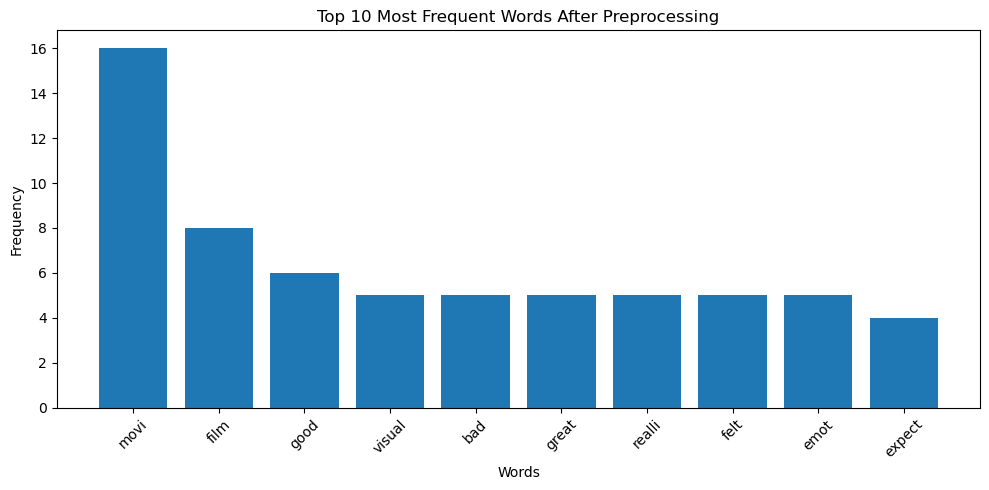

In [13]:
words = [w for w, _ in common_words]
counts = [c for _, c in common_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title('Top 10 Most Frequent Words After Preprocessing')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 12: Compare before and after preprocessing

In [33]:
raw_words = ' '.join(df['review'].astype(str)).split()
processed_words = all_words

print('Raw word count:', len(raw_words))
print('Processed word count:', len(processed_words))

Raw word count: 727
Processed word count: 413


## Step 13: Apply TFIDF

In [34]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
print(tfidf_feature_names)

['absolut' 'act' 'actor' 'actual' 'almost' 'amaz' 'annoy' 'asleep'
 'averag' 'aw' 'awkward' 'bad' 'badli' 'beauti' 'begin' 'best' 'better'
 'big' 'bland' 'bore' 'brilliant' 'care' 'carri' 'cast' 'charact' 'charm'
 'check' 'cheesi' 'clean' 'clever' 'clich' 'color' 'complet' 'confus'
 'core' 'creativ' 'definit' 'deliv' 'dialogu' 'direct' 'disappoint' 'done'
 'dont' 'drag' 'drama' 'dull' 'easi' 'edit' 'effect' 'els' 'emot' 'end'
 'energet' 'energi' 'enjoy' 'enough' 'entertain' 'even' 'everi' 'everyth'
 'excel' 'excit' 'execut' 'expect' 'experi' 'fail' 'fastpac' 'fell' 'felt'
 'film' 'final' 'finish' 'flashi' 'flat' 'follow' 'forc' 'forev' 'forgett'
 'fresh' 'friend' 'frustrat' 'fun' 'funni' 'gave' 'get' 'gon' 'good'
 'grab' 'great' 'guess' 'halfway' 'happen' 'heart' 'heartwarm' 'honestli'
 'hook' 'humor' 'hype' 'id' 'idea' 'impact' 'impress' 'interest'
 'introduc' 'ive' 'job' 'joke' 'keep' 'kept' 'kind' 'land' 'late' 'laugh'
 'lazi' 'lead' 'letdown' 'level' 'lie' 'like' 'littl' 'long' 'lo

In [37]:
tfidf_vectorizer = TfidfVectorizer(max_features=20)
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.head()

,act,bad,charact,emot,end,enjoy,expect,felt,film,good,great,honestli,littl,movi,pretti,realli,stori,time,visual,weak
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.645633,0.0,0.000000,0.000000,0.0,0.645633,0.0,0.407819,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.555659,0.0,0.0,0.0,0.0,0.831410,0.0
4,0.0,0.0,0.0,0.0,0.0,0.544055,0.000000,0.0,0.447802,0.488956,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.514199,0.0


## Reflection questions

1. Why do we convert text to lowercase?
2. What kinds of information might be lost when removing punctuation?
3. Is removing stopwords always a good idea?
4. What is one limitation of stemming?


## Student Activity: Apply Preprocessing Manually

Apply the following steps in order:<br>
Lowercasing <br> Remove punctuation <br> Remove special characters & numbers <br> Normalize repeated characters (e.g., doooing → doing) <br> Tokenization <br> Remove stopwords <br> Stemming

In [ ]:
text = "Patient is doooing MUCH better!!! BP was 150/95 yesterday, now 130/85 :) still complaining of headaaaache tho... prescribed 2 meds & follow-up in 2 weeks!!!"